# 05 — Additional Visualizations
Extra charts to complement EDA and model analysis.

In [19]:
# Setup
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import RAW_DIR
from src.visualize import save_current_fig
sns.set_context('talk')

In [20]:
df = pd.read_csv(RAW_DIR / 'ogun_weather.csv', parse_dates=[0], index_col=0)
df.head()

,temperature_c,humidity_pct,wind_speed_mps,precipitation_mm,surface_pressure_hpa
date,,,,,
2015-01-01 00:00:00+01:00,28.013043,53.521739,5.821739,0.0,10.001043
2015-01-02 00:00:00+01:00,27.583333,66.708333,5.304167,0.0,10.008292
2015-01-03 00:00:00+01:00,28.266667,62.791667,5.458333,0.0,10.021000
2015-01-04 00:00:00+01:00,27.716667,44.041667,6.500000,0.0,10.026333
2015-01-05 00:00:00+01:00,26.291667,28.291667,6.079167,0.0,10.018958


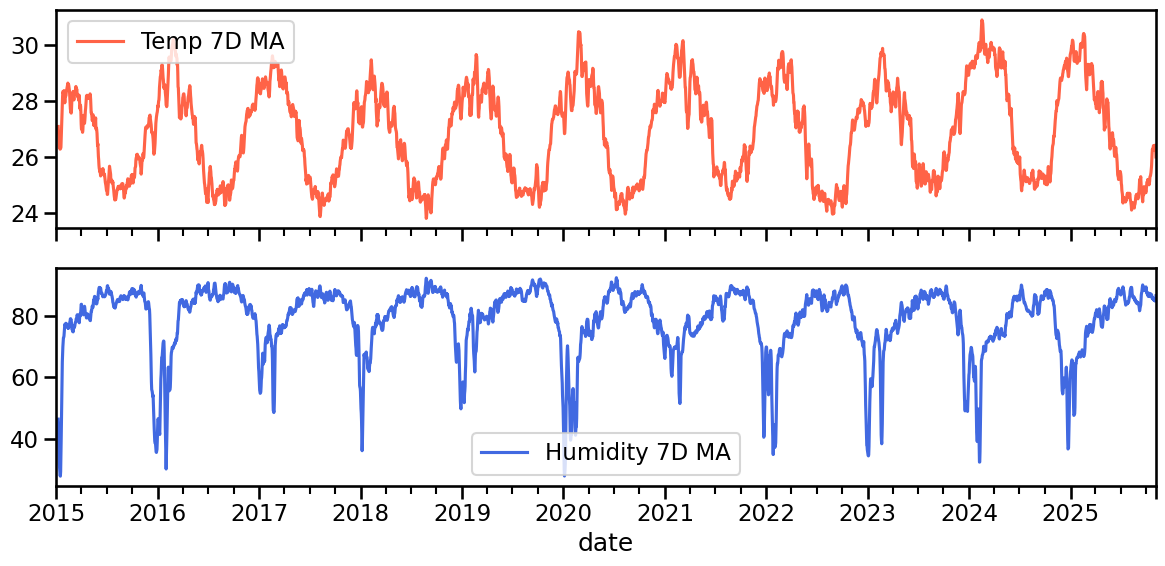

In [21]:
# Rolling averages for temperature and humidity
fig, ax = plt.subplots(2,1, figsize=(12,6), sharex=True)
df['temperature_c'].rolling(7).mean().plot(ax=ax[0], color='tomato', label='Temp 7D MA')
ax[0].legend()
df['humidity_pct'].rolling(7).mean().plot(ax=ax[1], color='royalblue', label='Humidity 7D MA')
ax[1].legend()
save_current_fig('rolling_avgs.png')
plt.show()

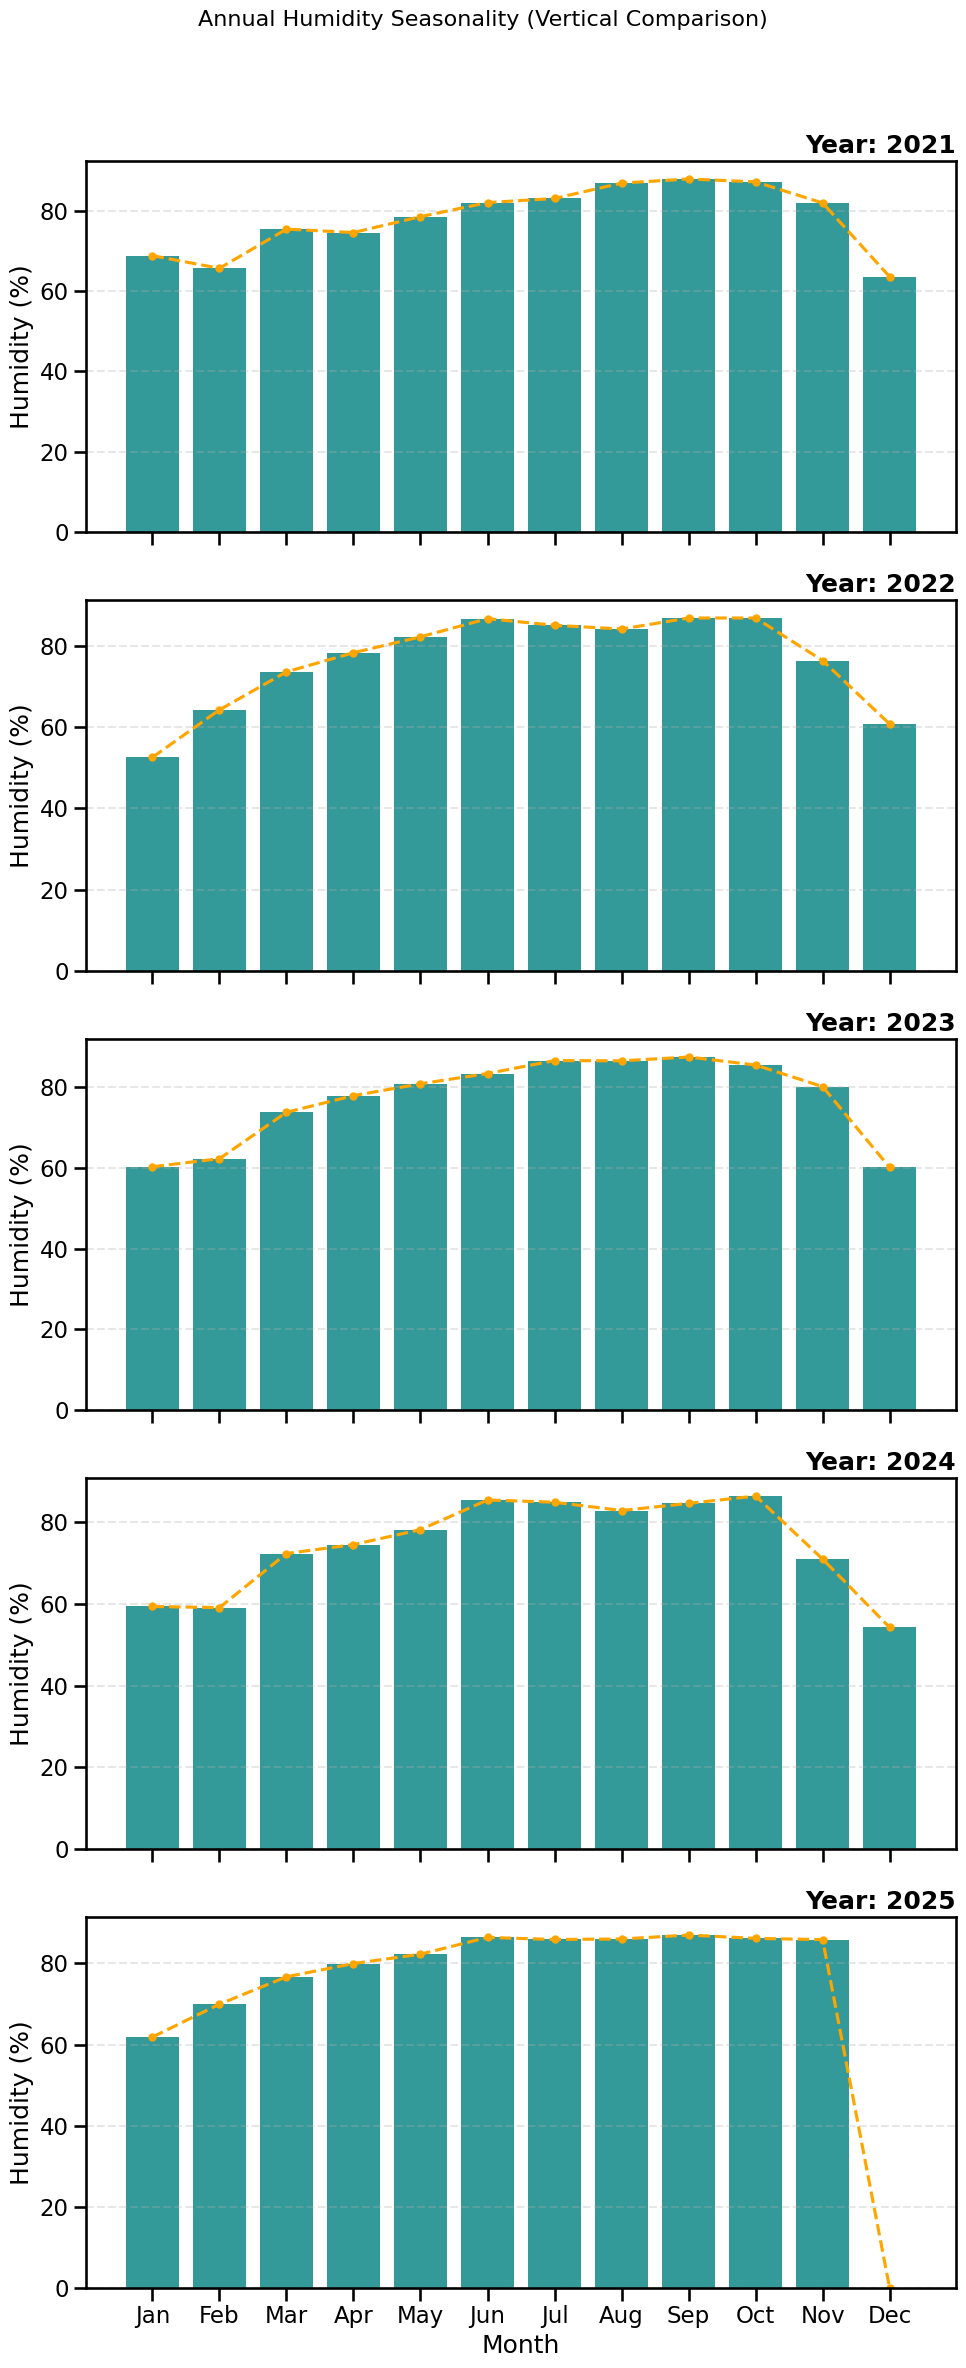

In [29]:
# 1. Setup years
df['year'] = df.index.year
df['month'] = df.index.month
years = sorted(df['year'].unique())[-5:]  # Last 5 years

# 2. Change to (rows=len(years), cols=1) for vertical stacking
# Increase the height (figsize) based on the number of years
fig, axes = plt.subplots(len(years), 1, figsize=(10, 5 * len(years)), sharex=True, squeeze=False)
axes = axes.flatten()

for i, year in enumerate(years):
    data = df[df['year'] == year]
    monthly_humidity = data.groupby('month')['humidity_pct'].mean()
    
    # Ensure all months 1-12 are present
    monthly_humidity = monthly_humidity.reindex(range(1, 13), fill_value=0)
    
    axes[i].bar(monthly_humidity.index, monthly_humidity.values, color='teal', alpha=0.8)
    axes[i].set_title(f'Year: {year}', loc='right', fontweight='bold')
    axes[i].set_ylabel('Humidity (%)')
    
    # Grid for easier reading of values
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)

    # add line connecting the tops of the bars
    axes[i].plot(monthly_humidity.index, monthly_humidity.values, color='orange',
    linestyle='--', marker='o', markersize=5)

    
    # Only the bottom plot gets the Month labels for a cleaner look
    if i == len(years) - 1:
        axes[i].set_xticks(range(1, 13))
        axes[i].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
        axes[i].set_xlabel('Month')

fig.suptitle('Annual Humidity Seasonality (Vertical Comparison)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

In [11]:
df.shape

(10, 14)